# Heart rate data

In [3]:
import numpy as np
# Random seed random.seed(seed=None)
np.random.seed(42)
# Generate dummy heart rate data
high_phase_data = np.random.randint(95, 130, size=500)
normal_phase_data = np.random.randint(50, 120, size=440)
low_phase_data = np.random.randint(35, 70, size=500)
heart_rate_data = np.concatenate([high_phase_data, normal_phase_data, low_phase_data])
# Store the data as csv
np.savetxt('heart_rate_data.csv', heart_rate_data, delimiter=',')

# MI Image

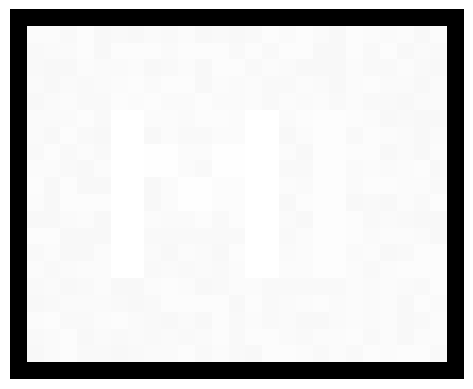

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

# Step 1: Generate an MRI Image with "MI" embedded
def generate_mri_image_with_mi():
    # Create a 2D array with random noise
    mri_image = np.random.randint(low=248, high=253, size=(20, 25), dtype=np.uint8)
    
    # Embed the letter "M"
    mri_image[5:15, 5:7] = 255  # Vertical part of M
    mri_image[7:9,  7:9] = 254  # First slant of M
    mri_image[9:11, 9:11] = 254  # First slant of M
    mri_image[7:9, 11:13] = 254  # Second slant of M
    mri_image[5:15, 13:15] = 255  # Vertical part of M
        
    # Embed the letter "I"
    mri_image[5:15, 17:19] = 253  # Vertical part of I  

    # add black border
    mri_image = np.pad(mri_image, pad_width=1, mode='constant', constant_values=0)
      
    return mri_image

# Generate the image
mri_image = generate_mri_image_with_mi()


# Analyze the image
# Plot the results
plt.imshow(mri_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# Step 2: Save the image as imagefile
plt.imsave('mri_image.png', mri_image, cmap='gray', vmin=0, vmax=255)

# fictitious_patient_data

In [10]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generating fictitious data for 100 patients
num_patients = 100

# special id list (Prime numbers)
special_id = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]

# Generate random data for each column
patient_id = range(1, num_patients + 1)
age = np.random.randint(18, 90, size=num_patients)
gender = np.random.choice(['Male', 'Female','male','female'], size=num_patients)
primary_diagnosis = np.random.choice(['Diabetes', 'Heart Failure', 'COPD', 'Pneumonia', 'Kidney Disease','diabetes', 'Heart failure', 'pneumonia', 'Kidney disease'], size=num_patients)
num_comorbidities = np.where(np.isin(patient_id, special_id), np.random.randint(5, 6, size=num_patients), np.random.randint(0, 2, size=num_patients))
length_of_stay = np.where(np.isin(patient_id, special_id), np.random.randint(1, 4, size=num_patients), np.random.randint(5, 21, size=num_patients))
discharge_destination = np.random.choice(['Home', 'Rehabilitation Center', 'Nursing Home', 'Home with Services'], size=num_patients)
follow_up_appointment = np.random.choice([0, 1], size=num_patients)
readmitted_within_30_days = np.where(np.isin(patient_id, special_id), np.random.choice([0, 1], size=num_patients), 0)

# Create a DataFrame
data = pd.DataFrame({
    'Patient_ID': patient_id,
    'Age': age,
    'Gender': gender,
    'Primary_Diagnosis': primary_diagnosis,
    'Num_Comorbidities': num_comorbidities,
    'Length_of_Stay': length_of_stay,
    'Discharge_Destination': discharge_destination,
    'Follow_Up_Appointment': follow_up_appointment,
    'Readmitted_Within_30_Days': readmitted_within_30_days
})

# Save the data to a CSV file
csv_file_path = 'fictitious_hospital_data.csv'
data.to_csv(csv_file_path, index=False)

csv_file_path


'fictitious_hospital_data.csv'

# medication adherence datasets

In [12]:
import pandas as pd
import numpy as np

# Setting the seed for reproducibility
np.random.seed(42)

# List of specific patient IDs
special_ids = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]

# Generating fictitious data for 100 patients
patient_ids = np.arange(100) + 1
age = np.where(np.isin(patient_ids, special_ids), 
               np.random.randint(65, 90, size=100), 
               np.random.randint(30, 70, size=100))
gender = np.random.choice(['Male', 'Female'], size=100)
conditions = np.random.choice(['Hypertension', 'Diabetes', 'Hypertension & Diabetes'], size=100)
num_medications = np.where(np.isin(patient_ids, special_ids),np.random.randint(5, 15, size=100), np.random.randint(0, 10, size=100))
adherence_level = np.random.choice(['High', 'Medium', 'Low'], size=100)

# Creating the patients DataFrame
patients_df = pd.DataFrame({
    'Patient_ID': patient_ids,
    'Age': age,
    'Gender': gender,
    'Condition': conditions,
    'Num_Medications': num_medications,
    'Adherence_Level': adherence_level
})

# Generating fictitious data for 300 visits (3 visits per patient on average)
visit_dates = pd.date_range(start='2023-01-01', periods=100, freq='7D')
visit_dates = np.tile(visit_dates, 3)

# Randomly shuffle and select dates to avoid uniform distribution
visit_dates = np.random.choice(visit_dates, 300, replace=False)
patient_ids_for_visits = np.random.choice(patient_ids, 300, replace=True)
visit_type = np.random.choice(['Routine Checkup', 'Emergency Visit', 'Follow-up'], size=300)
prescribed_doses = np.random.randint(20, 90, size=300)
# Generating reported doses based on condition
reported_doses_taken = np.where(np.isin(patient_ids_for_visits, special_ids), 
                                prescribed_doses - np.random.randint(25, 90, size=300), 
                                prescribed_doses - np.random.randint(0, 5, size=300))
reported_doses_taken = np.where(reported_doses_taken < 0, 0, reported_doses_taken)

# Creating the visits DataFrame
visits_df = pd.DataFrame({
    'Visit_ID': np.arange(300) + 1,
    'Patient_ID': patient_ids_for_visits,
    'Visit_Date': visit_dates,
    'Visit_Type': visit_type,
    'Prescribed_Doses': prescribed_doses,
    'Reported_Doses_Taken': reported_doses_taken
})

# Saving the data to CSV files
patients_csv_path = 'fictitious_patients.csv'
visits_csv_path = 'fictitious_visits.csv'

patients_df.to_csv(patients_csv_path, index=False)
visits_df.to_csv(visits_csv_path, index=False)

patients_csv_path, visits_csv_path


('fictitious_patients.csv', 'fictitious_visits.csv')